# Semantic Clustering of Customer Feedback

This notebook uses sentence embeddings to cluster customer comments based on semantic similarity.

Unlike bag-of-words topic models, sentence embeddings capture the meaning of comments more effectively, allowing us to identify more coherent feedback themes.

In [1]:
import pandas as pd

comments_df = pd.read_csv("../data/processed/customer_feedback_comments_cleaned.csv")

comments_df.shape

(478, 17)

## Load Sentence Embedding Model

We use a pretrained sentence-transformer model to convert each customer
comment into a dense semantic vector.

These embeddings capture meaning better than simple word-count methods.

In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Generate Sentence Embeddings

Each customer comment is converted into a dense vector representation
using the sentence-transformer model. These embeddings capture the
semantic meaning of comments.

In [3]:
comments = comments_df["clean_comment"].tolist()

embeddings = model.encode(
    comments,
    show_progress_bar=True
)

len(embeddings)

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

478

## Cluster Comments by Semantic Similarity

We apply KMeans clustering to group customer comments into semantically
similar clusters based on their sentence embeddings.

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
comments_df["semantic_cluster"] = kmeans.fit_predict(embeddings)

comments_df["semantic_cluster"].value_counts().sort_index()

semantic_cluster
0    116
1     65
2     98
3    124
4     75
Name: count, dtype: int64

## Inspect Semantic Clusters

We inspect example comments from each cluster to understand the themes
captured by the semantic embeddings.

In [5]:
for cluster in sorted(comments_df["semantic_cluster"].unique()):
    
    print(f"\nCLUSTER {cluster}")
    print("-" * 40)
    
    sample_comments = comments_df[
        comments_df["semantic_cluster"] == cluster
    ]["clean_comment"].sample(5, random_state=42)
    
    for comment in sample_comments:
        print(comment)


CLUSTER 0
----------------------------------------
i found it very difficult to understand your agents over the phone and rather than agreeing to my eyes they tried to sell me something different
telephone conversation very hard to understandbut the installation went really good really nice man who installed it and explained everything i needed to know
cut my internet off asked for router to be sent after 500 tracker shows between 10 and 12
very helpful and positive response when i rang to set up broadband thank you
dee who took me through the ordering process could not have been more helpful she went over and above

CLUSTER 1
----------------------------------------
brilliant customer service
great service quick set up
great help and amazing service
quick efficient service with easy set up
very good customer service

CLUSTER 2
----------------------------------------
the service is superp i really appreciate the turnaround as well as the constant updates regarding progress company me

In [6]:
cluster_names = {
    0: "Service Issues and Support",
    1: "Highly Positive Feedback",
    2: "Service Value and Installation",
    3: "Agent Communication and Support",
    4: "Operational and Communication Issues"
}

comments_df["semantic_topic"] = comments_df["semantic_cluster"].map(cluster_names)

Task was destroyed but it is pending!
task: <Task pending name='Task-344' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\jishm\PROJECTS\customer-script-impact-intelligence\venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-345' coro=<Kernel.shell_main() running at C:\Users\jishm\PROJECTS\customer-script-impact-intelligence\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\jishm\PROJECTS\customer-script-impact-intelligence\venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Exception ignored in: <coroutine object Kernel.shell_main at 0x000002328FF66A40>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Exception ignored in: <coroutine object Kernel.shell_main at 0x000002328FF66A40>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Task was destro

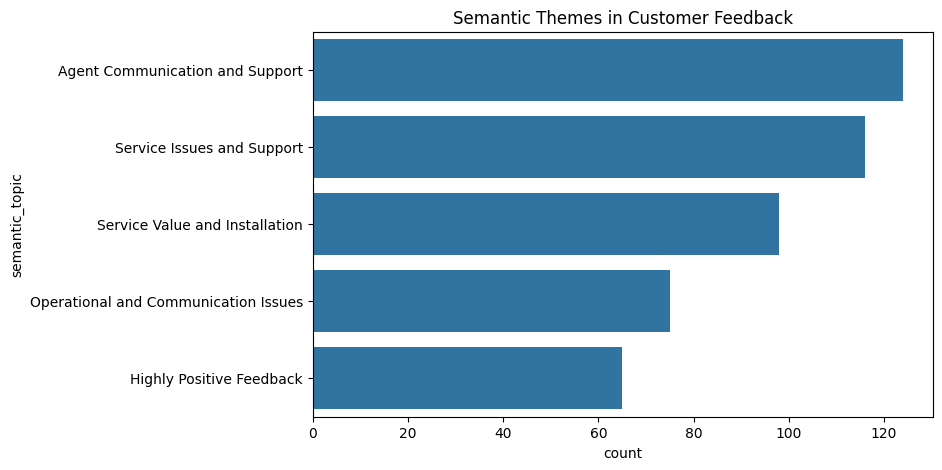

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    y=comments_df["semantic_topic"],
    order=comments_df["semantic_topic"].value_counts().index
)

plt.title("Semantic Themes in Customer Feedback")

plt.savefig("../outputs/figures/semantic_topics.png", dpi=300)

plt.show()

In [8]:

#Which semantic themes appear more in treatment vs control?
pd.crosstab(
    comments_df["semantic_topic"],
    comments_df["experiment_group"]
)

experiment_group,control,treatment
semantic_topic,,
Agent Communication and Support,72,52
Highly Positive Feedback,42,23
Operational and Communication Issues,46,29
Service Issues and Support,67,49
Service Value and Installation,57,41


The decision-support script did not significantly improve customer satisfaction scores or overall sentiment. However, semantic analysis indicates a modest increase in feedback related to agent explanations and communication clarity in the treatment group. This suggests that while the script may influence how agents communicate decisions, it does not meaningfully impact overall customer satisfaction, which appears to be driven more strongly by operational factors such as installation experience.

## Semantic topic vs experiment group chart

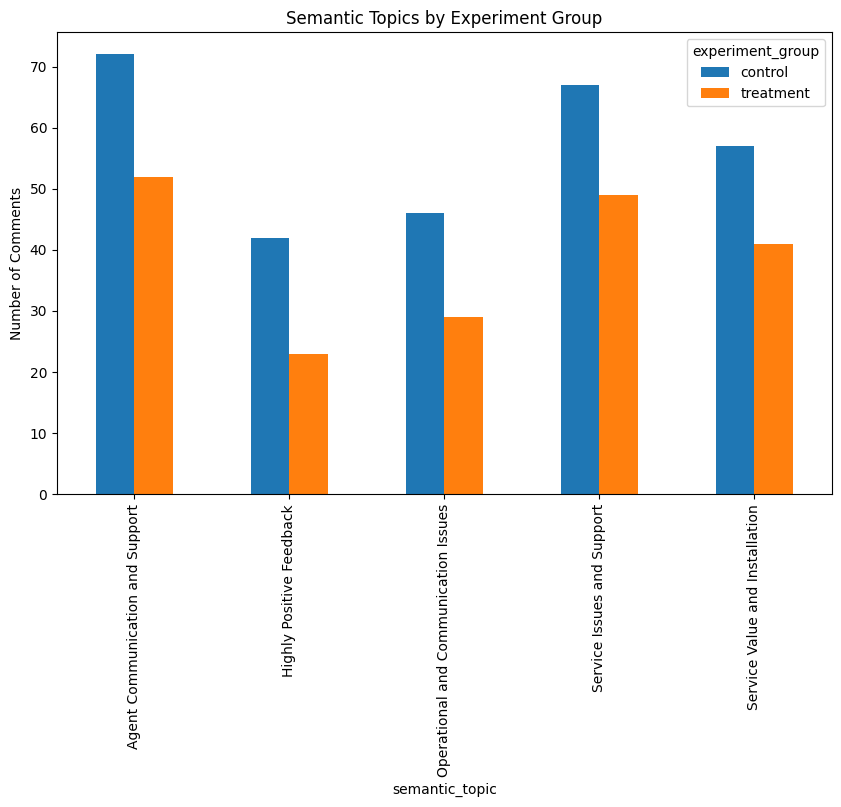

In [9]:
semantic_exp = pd.crosstab(
    comments_df["semantic_topic"],
    comments_df["experiment_group"]
)

semantic_exp.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Semantic Topics by Experiment Group")
plt.ylabel("Number of Comments")

plt.savefig("../outputs/figures/semantic_topics_by_experiment.png", dpi=300)

plt.show()